# Predictive Modeling
## Respiratory Disease Prediction from Environmental Factors
**Team:** Gowrav Lakshmipathy | Priya Dilip Bajaria | Nandini Nandan Narvekar

---

**Input:** `data/processed/features_daily.csv` — 1,119 rows × 16 columns  
**Output:** `outputs/figures/model_*.png`

## Three Models

| Model | Type | Feature set |
|---|---|---|
| Ridge Regression | Linear, regularized | Cyclic month encoding (`month_sin` / `month_cos`) |
| Random Forest | Tree ensemble | Raw `month` integer, `season_num` |
| XGBoost | Gradient boosting | Same as Random Forest |

## Evaluation strategy

All models use **5-fold TimeSeriesSplit** cross-validation. Each fold trains on all prior data and tests on the next contiguous block, preserving temporal order. This corrects the March baseline failure (train R² = 0.79, test R² = −0.70), which was caused by a single 80/20 cut that put all summer data in the test set.

## Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('WARNING: xgboost not installed. Run: pip install xgboost')

warnings.filterwarnings('ignore')
os.makedirs('outputs/figures', exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 9

# ── Load features dataset ─────────────────────────────────────────────────────
features = pd.read_csv('data/processed/features_daily.csv', parse_dates=['date'])
features = features.sort_values('date').reset_index(drop=True)

# Continuous time trend: captures multi-year drift that cyclic month encoding cannot.
# Scaled to years so its coefficient is interpretable alongside other features.
features['year_trend'] = (features['date'] - features['date'].min()).dt.days / 365.25

for lag in [7, 14, 30]:
    features[f'resp_lag{lag}'] = features['pct_respiratory'].shift(lag)
features = features.dropna().reset_index(drop=True)

TARGET = 'pct_respiratory'

# Linear model features: cyclic month encoding avoids the Jan-1 / Dec-12
# discontinuity that would mislead a linear model. year_trend captures
# the multi-year drift across the 3-year study period.
LINEAR_FEATURES = [
    'temperature', 'humidity', 'no2_lag12', 'ozone_lag13', 'pm25_lag14',
    'month_sin', 'month_cos', 'day_of_week', 'is_weekend', 'year_trend',
    'resp_lag7', 'resp_lag14', 'resp_lag30',
]

# Tree model features: trees handle ordinal integers natively; raw month and
# season_num add interpretable splits without needing trigonometric encoding.
TREE_FEATURES = [
    'temperature', 'humidity', 'no2_lag12', 'ozone_lag13', 'pm25_lag14',
    'month', 'day_of_week', 'is_weekend', 'season_num', 'year_trend',
    'resp_lag7', 'resp_lag14', 'resp_lag30',
]

X_linear = features[LINEAR_FEATURES].values
X_tree   = features[TREE_FEATURES].values
y        = features[TARGET].values
dates    = features['date'].values

print(f'Dataset: {features.shape[0]} rows (30 dropped for autoregressive lags)')
print(f'Date range: {features["date"].min().date()} to {features["date"].max().date()}')
print(f'Target: {y.min():.2f}% – {y.max():.2f}%  (mean {y.mean():.2f}%)')
print(f'XGBoost available: {HAS_XGB}')


Dataset: 1089 rows (30 dropped for autoregressive lags)
Date range: 2022-11-08 to 2025-10-31
Target: 7.09% – 26.58%  (mean 13.14%)
XGBoost available: True


---
## Evaluation Setup

`TimeSeriesSplit(n_splits=5, test_size=90)` produces 5 expanding folds, each with a fixed **90-day (~1 quarter) test window**.

**Why `test_size=90`:** The default split divided ~1,119 rows into ~186-row test blocks (~6 months each), causing folds 1/3/5 to always test on the opposite season from training — yielding systematically negative R². With `test_size=90`, fold 1 trains on ~669 rows (~22 months), guaranteeing at least one full seasonal cycle before the first test block.

**Why `year_trend`:** The 3-year study period spans a multi-year drift in baseline respiratory illness rates. Cyclic `month_sin`/`month_cos` encoding captures within-year seasonality but not this trend; `year_trend` (days since start ÷ 365.25) gives both linear and tree models a continuous signal for it.

Metrics reported: **R²**, **RMSE** (percentage points), **MAE** (percentage points).

In [2]:
N_SPLITS = 5
# test_size=90 fixes seasonal mismatch: each test block covers one quarter,
# so fold 1 trains on ~22 months — enough to see a full seasonal cycle before testing.
tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=90)

def cv_evaluate(model, X, y, cv, scale=False):
    """Time-series cross-validation. Returns per-fold DataFrame."""
    rows = []
    for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        if scale:
            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)

        model.fit(X_tr, y_tr)
        rows.append({
            'fold':      fold + 1,
            'n_train':   len(train_idx),
            'n_test':    len(test_idx),
            'train_r2':  r2_score(y_tr,  model.predict(X_tr)),
            'test_r2':   r2_score(y_te,  model.predict(X_te)),
            'test_rmse': np.sqrt(mean_squared_error(y_te, model.predict(X_te))),
            'test_mae':  mean_absolute_error(y_te, model.predict(X_te)),
        })

    df = pd.DataFrame(rows)
    hdr = f'  {"Fold":<5}  {"N train":>8}  {"N test":>7}  {"Train R²":>9}  {"Test R²":>8}  {"RMSE":>6}  {"MAE":>6}'
    print(hdr)
    print('  ' + '-' * 62)
    for _, r in df.iterrows():
        print(f'  {int(r.fold):<5}  {int(r.n_train):>8}  {int(r.n_test):>7}  '
              f'{r.train_r2:>9.3f}  {r.test_r2:>8.3f}  {r.test_rmse:>6.3f}  {r.test_mae:>6.3f}')
    print('  ' + '-' * 62)
    print(f'  {"Mean":<5}  {"":>8}  {"":>7}  '
          f'{df.train_r2.mean():>9.3f}  {df.test_r2.mean():>8.3f}  '
          f'{df.test_rmse.mean():>6.3f}  {df.test_mae.mean():>6.3f}')
    print(f'  {"±":<5}  {"":>8}  {"":>7}  '
          f'{df.train_r2.std():>9.3f}  {df.test_r2.std():>8.3f}  '
          f'{df.test_rmse.std():>6.3f}  {df.test_mae.std():>6.3f}')
    return df

all_cv   = {}   # fold-level DataFrames
all_summ = {}   # summary dicts for comparison table


---
## Model A — Ridge Regression

**Why Ridge over OLS:** Temperature, NO₂, and ozone share strong seasonal patterns (they are mutually correlated). Ridge regularisation shrinks coefficients of collinear features, reducing variance without removing them from the model.

**Why cyclic month encoding:** Raw month (1–12) treats January and December as maximally dissimilar. `month_sin` / `month_cos` place them adjacently on a unit circle, allowing a linear model to learn continuous seasonal transitions.

**Alpha search:** `RidgeCV` performs efficient leave-one-out CV internally across `[0.1, 1, 10, 100, 1000]` to select the best regularisation strength.

In [3]:
ridge = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0, 1000.0])

print('Model A — Ridge Regression')
print(f'Features ({len(LINEAR_FEATURES)}): {LINEAR_FEATURES}')
print()
ridge_cv = cv_evaluate(ridge, X_linear, y, tscv, scale=True)

# Fit on full data for coefficient inspection
sc_full = StandardScaler()
ridge.fit(sc_full.fit_transform(X_linear), y)
print(f'\nSelected alpha: {ridge.alpha_:.1f}')

coef_df = (pd.DataFrame({'feature': LINEAR_FEATURES, 'coef': ridge.coef_})
             .assign(abs_coef=lambda d: d.coef.abs())
             .sort_values('abs_coef', ascending=False))
print('\nCoefficients (sorted by |coef|):')
for _, row in coef_df.iterrows():
    bar = '█' * int(row.abs_coef / coef_df.abs_coef.max() * 20)
    print(f'  {row.feature:<20}  {row.coef:>+7.4f}  {bar}')

all_cv['Ridge']   = ridge_cv
all_summ['Ridge'] = {
    'mean_r2':  ridge_cv.test_r2.mean(),
    'std_r2':   ridge_cv.test_r2.std(),
    'rmse':     ridge_cv.test_rmse.mean(),
    'mae':      ridge_cv.test_mae.mean(),
    'fold_r2':  ridge_cv.test_r2.tolist(),
}


Model A — Ridge Regression
Features (13): ['temperature', 'humidity', 'no2_lag12', 'ozone_lag13', 'pm25_lag14', 'month_sin', 'month_cos', 'day_of_week', 'is_weekend', 'year_trend', 'resp_lag7', 'resp_lag14', 'resp_lag30']

  Fold    N train   N test   Train R²   Test R²    RMSE     MAE
  --------------------------------------------------------------
  1           639       90      0.960     0.172   0.781   0.697
  2           729       90      0.959     0.720   1.643   1.262
  3           819       90      0.951     0.970   0.552   0.453
  4           909       90      0.953     0.909   0.400   0.316
  5           999       90      0.958     0.191   0.822   0.728
  --------------------------------------------------------------
  Mean                          0.956     0.592   0.840   0.691
  ±                             0.004     0.386   0.481   0.362

Selected alpha: 0.1

Coefficients (sorted by |coef|):
  resp_lag7             +4.9068  ████████████████████
  resp_lag14            -1

---
## Model B — Random Forest

**Why Random Forest:** Trees capture non-linear and interaction effects that a linear model cannot. The seasonal interaction — where NO₂ correlates positively with illness in winter but negatively in summer — requires conditional splits. Random Forest handles this without explicit interaction terms.

**Hyperparameter choices:**
- `max_depth=8`: limits individual tree complexity to reduce overfitting on 1,119 rows
- `min_samples_leaf=10`: requires at least 10 samples per leaf (~1% of training data)
- `max_features=0.6`: subsamples 60% of features per split to decorrelate trees
- `n_estimators=300`: enough trees for stable importances; diminishing returns above ~200

In [4]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    max_features=0.6,
    random_state=42,
    n_jobs=-1,
)

print('Model B — Random Forest')
print(f'Features ({len(TREE_FEATURES)}): {TREE_FEATURES}')
print()
rf_cv = cv_evaluate(rf, X_tree, y, tscv, scale=False)

# Fit on full data for feature importances
rf.fit(X_tree, y)
imp_df = (pd.DataFrame({'feature': TREE_FEATURES, 'importance': rf.feature_importances_})
            .sort_values('importance', ascending=False))
print('\nFeature importances (mean decrease in impurity):')
for _, row in imp_df.iterrows():
    bar = '█' * int(row.importance / imp_df.importance.max() * 25)
    print(f'  {row.feature:<20}  {row.importance:.4f}  {bar}')

all_cv['Random Forest']   = rf_cv
all_summ['Random Forest'] = {
    'mean_r2':    rf_cv.test_r2.mean(),
    'std_r2':     rf_cv.test_r2.std(),
    'rmse':       rf_cv.test_rmse.mean(),
    'mae':        rf_cv.test_mae.mean(),
    'fold_r2':    rf_cv.test_r2.tolist(),
    'importances': dict(zip(TREE_FEATURES, rf.feature_importances_)),
}


Model B — Random Forest
Features (13): ['temperature', 'humidity', 'no2_lag12', 'ozone_lag13', 'pm25_lag14', 'month', 'day_of_week', 'is_weekend', 'season_num', 'year_trend', 'resp_lag7', 'resp_lag14', 'resp_lag30']

  Fold    N train   N test   Train R²   Test R²    RMSE     MAE
  --------------------------------------------------------------
  1           639       90      0.980     0.754   0.426   0.328
  2           729       90      0.981     0.609   1.943   1.380
  3           819       90      0.979     0.862   1.175   0.855
  4           909       90      0.977     0.576   0.862   0.731
  5           999       90      0.980     0.626   0.559   0.444
  --------------------------------------------------------------
  Mean                          0.979     0.685   0.993   0.747
  ±                             0.001     0.120   0.605   0.412

Feature importances (mean decrease in impurity):
  resp_lag7             0.5575  █████████████████████████
  resp_lag14            0.2644  █

---
## Model C — XGBoost

**Why XGBoost:** Gradient boosting builds trees sequentially, each correcting the residuals of the previous one. On tabular data of this size (1,119 rows) it typically outperforms Random Forest because the sequential correction reduces both bias and variance more efficiently than the independent bagging in RF.

**Hyperparameter choices:**
- `learning_rate=0.05`: small step size requires more trees but generalises better
- `max_depth=4`: shallower than RF default to prevent overfitting on the seasonal residuals
- `subsample=0.8` + `colsample_bytree=0.8`: row and feature subsampling add regularisation
- `n_estimators=300`: sufficient for convergence at lr=0.05

In [5]:
if HAS_XGB:
    xgb_model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0,
    )

    print('Model C — XGBoost')
    print(f'Features ({len(TREE_FEATURES)}): {TREE_FEATURES}')
    print()
    xgb_cv = cv_evaluate(xgb_model, X_tree, y, tscv, scale=False)

    xgb_model.fit(X_tree, y)
    ximp_df = (pd.DataFrame({'feature': TREE_FEATURES,
                              'importance': xgb_model.feature_importances_})
               .sort_values('importance', ascending=False))
    print('\nFeature importances (gain):')
    for _, row in ximp_df.iterrows():
        bar = '█' * int(row.importance / ximp_df.importance.max() * 25)
        print(f'  {row.feature:<20}  {row.importance:.4f}  {bar}')

    all_cv['XGBoost']   = xgb_cv
    all_summ['XGBoost'] = {
        'mean_r2':    xgb_cv.test_r2.mean(),
        'std_r2':     xgb_cv.test_r2.std(),
        'rmse':       xgb_cv.test_rmse.mean(),
        'mae':        xgb_cv.test_mae.mean(),
        'fold_r2':    xgb_cv.test_r2.tolist(),
        'importances': dict(zip(TREE_FEATURES, xgb_model.feature_importances_)),
    }
else:
    print('XGBoost not available — install with: pip install xgboost')


Model C — XGBoost
Features (13): ['temperature', 'humidity', 'no2_lag12', 'ozone_lag13', 'pm25_lag14', 'month', 'day_of_week', 'is_weekend', 'season_num', 'year_trend', 'resp_lag7', 'resp_lag14', 'resp_lag30']

  Fold    N train   N test   Train R²   Test R²    RMSE     MAE
  --------------------------------------------------------------
  1           639       90      0.999     0.756   0.424   0.327
  2           729       90      0.999     0.583   2.008   1.409
  3           819       90      0.998     0.668   1.825   1.535
  4           909       90      0.998     0.670   0.762   0.633
  5           999       90      0.998     0.769   0.440   0.341
  --------------------------------------------------------------
  Mean                          0.998     0.689   1.091   0.849
  ±                             0.000     0.076   0.768   0.583

Feature importances (gain):
  resp_lag7             0.7707  █████████████████████████
  resp_lag14            0.1236  ████
  month                

---
## Model Comparison

In [6]:
print(f'  {"Model":<16}  {"CV R² mean":>10}  {"± std":>7}  {"RMSE (pp)":>10}  {"MAE (pp)":>9}')
print('  ' + '-' * 58)
for name, s in all_summ.items():
    print(f'  {name:<16}  {s["mean_r2"]:>10.3f}  ±{s["std_r2"]:>6.3f}  '
          f'{s["rmse"]:>10.3f}  {s["mae"]:>9.3f}')

best_name = max(all_summ, key=lambda k: all_summ[k]['mean_r2'])
print(f'\nBest model: {best_name}  (CV R² = {all_summ[best_name]["mean_r2"]:.3f})')
print()
print('RMSE and MAE are in percentage-point units (same scale as pct_respiratory).')
print('e.g., RMSE = 1.5 means predictions are on average 1.5 pp off the actual % of ED visits.')


  Model             CV R² mean    ± std   RMSE (pp)   MAE (pp)
  ----------------------------------------------------------
  Ridge                  0.592  ± 0.386       0.840      0.691
  Random Forest          0.685  ± 0.120       0.993      0.747
  XGBoost                0.689  ± 0.076       1.091      0.849

Best model: XGBoost  (CV R² = 0.689)

RMSE and MAE are in percentage-point units (same scale as pct_respiratory).
e.g., RMSE = 1.5 means predictions are on average 1.5 pp off the actual % of ED visits.


---
## Figure 1 — Actual vs Predicted (Time Series)

**Chart type: Line chart with train / test shading**

The best model is trained on the first 80% of dates and evaluated on the remaining 20%. Both the actual and predicted values are plotted as continuous lines on the same axis across the full study period, with a vertical dashed line marking the train/test boundary. This makes it immediately visible whether the model captures seasonal cycles and where it fails.

A scatter plot of actual vs predicted would hide the temporal structure — it would show correlation strength but not reveal whether prediction errors cluster in specific seasons. A bar chart is inappropriate for a continuous time series.

80/20 split — Test R²: 0.785  |  RMSE: 0.667 pp


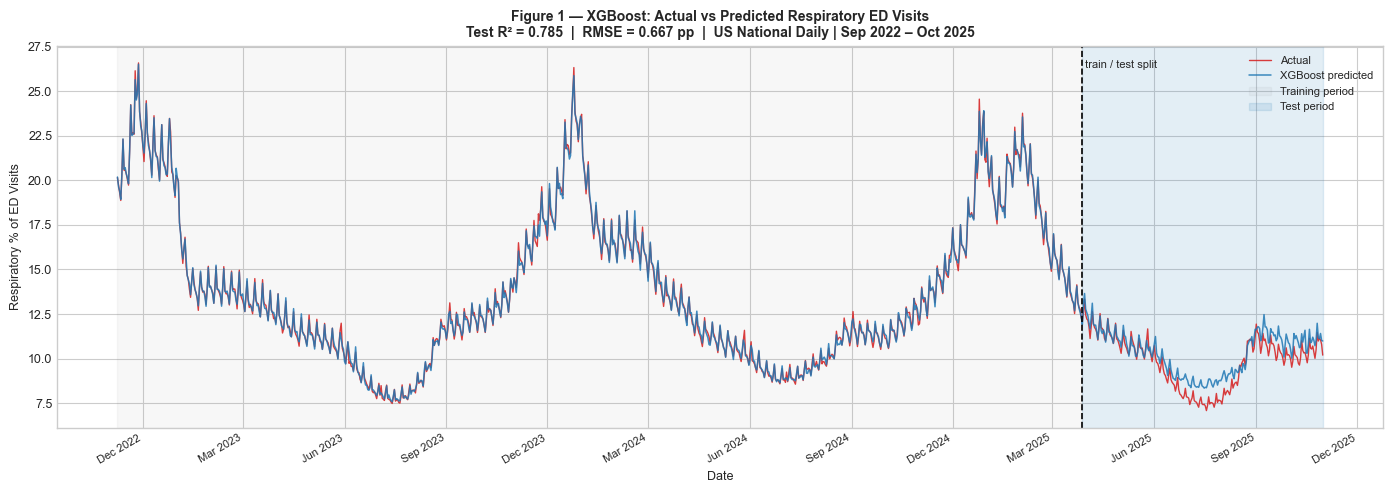

Saved: outputs/figures/model_01_actual_vs_predicted.png


In [7]:
# Train on first 80% of the time-ordered dataset
split_idx = int(0.8 * len(features))
split_date = features['date'].iloc[split_idx]

# Use the best model (refit on 80% training portion)
if best_name == 'Ridge':
    final_model = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0, 1000.0])
    sc80 = StandardScaler()
    X_tr80 = sc80.fit_transform(X_linear[:split_idx])
    X_all  = sc80.transform(X_linear)
    final_model.fit(X_tr80, y[:split_idx])
    y_pred = final_model.predict(X_all)
elif best_name == 'Random Forest':
    final_model = RandomForestRegressor(
        n_estimators=300, max_depth=8, min_samples_leaf=10,
        max_features=0.6, random_state=42, n_jobs=-1)
    final_model.fit(X_tree[:split_idx], y[:split_idx])
    y_pred = final_model.predict(X_tree)
else:  # XGBoost
    final_model = XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
    final_model.fit(X_tree[:split_idx], y[:split_idx])
    y_pred = final_model.predict(X_tree)

# Metrics on test portion
y_test_actual = y[split_idx:]
y_test_pred   = y_pred[split_idx:]
test_r2   = r2_score(y_test_actual, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred))
print(f'80/20 split — Test R²: {test_r2:.3f}  |  RMSE: {test_rmse:.3f} pp')

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(features['date'], y,       color='#d62728', linewidth=1.0,
        label='Actual', alpha=0.9)
ax.plot(features['date'], y_pred,  color='#1f77b4', linewidth=1.1,
        label=f'{best_name} predicted', alpha=0.85)

# Shade train / test regions
ax.axvspan(features['date'].iloc[0], split_date,
           alpha=0.06, color='gray', label='Training period')
ax.axvspan(split_date, features['date'].iloc[-1],
           alpha=0.12, color='#1f77b4', label='Test period')
ax.axvline(split_date, color='black', linewidth=1.2, linestyle='--')
ax.text(split_date, ax.get_ylim()[1] * 0.97, ' train / test split',
        fontsize=8, va='top')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Respiratory % of ED Visits', fontsize=9)
ax.set_xlabel('Date', fontsize=9)
ax.set_title(
    f'Figure 1 — {best_name}: Actual vs Predicted Respiratory ED Visits\n'
    f'Test R² = {test_r2:.3f}  |  RMSE = {test_rmse:.3f} pp  |  '
    f'US National Daily | Sep 2022 – Oct 2025',
    fontsize=10, fontweight='bold'
)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('outputs/figures/model_01_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/model_01_actual_vs_predicted.png')


---
## Figure 2 — Feature Importance

**Chart type: Horizontal grouped bar chart (RF alongside XGBoost)**

Feature importance quantifies which inputs the model relies on most. Horizontal bars are chosen because the feature names are long and would require rotation on a vertical axis. Showing RF and XGBoost side by side in the same figure makes it possible to verify that both models agree on the ranking, which increases confidence that the importance is real and not an artefact of one algorithm's internal metric.

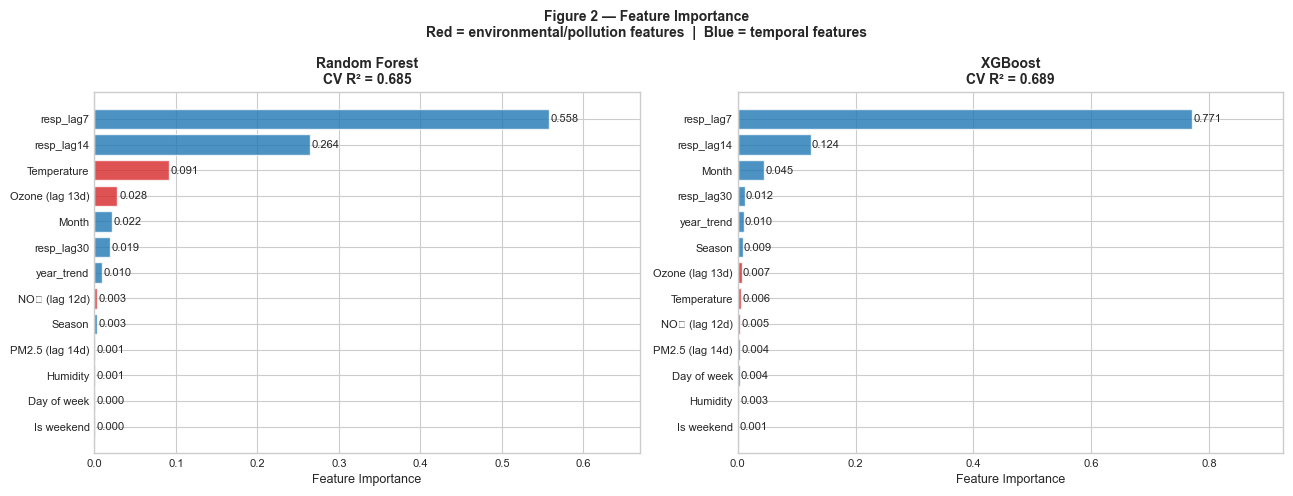

Saved: outputs/figures/model_02_feature_importance.png


In [8]:
if 'Random Forest' in all_summ and 'XGBoost' in all_summ:
    n_models = 2
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
    model_items = [('Random Forest', all_summ['Random Forest']['importances']),
                   ('XGBoost',       all_summ['XGBoost']['importances'])]
else:
    n_models = 1
    fig, axes = plt.subplots(1, 1, figsize=(7, 5))
    axes = [axes]
    model_items = [('Random Forest', all_summ['Random Forest']['importances'])]

FEAT_LABELS = {
    'temperature':  'Temperature',
    'humidity':     'Humidity',
    'no2_lag12':    'NO₂ (lag 12d)',
    'ozone_lag13':  'Ozone (lag 13d)',
    'pm25_lag14':   'PM2.5 (lag 14d)',
    'month':        'Month',
    'day_of_week':  'Day of week',
    'is_weekend':   'Is weekend',
    'season_num':   'Season',
}

for ax, (mname, imp_dict) in zip(axes, model_items):
    imp_s = pd.Series(imp_dict).rename(index=FEAT_LABELS).sort_values()
    colors = ['#d62728' if 'Temperature' in f or 'NO₂' in f or 'Ozone' in f
              else '#1f77b4' for f in imp_s.index]
    bars = ax.barh(imp_s.index, imp_s.values, color=colors, alpha=0.80, edgecolor='white')
    for bar, val in zip(bars, imp_s.values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', ha='left', fontsize=8)
    ax.set_xlabel('Feature Importance', fontsize=9)
    ax.set_xlim(0, imp_s.max() * 1.20)
    ax.tick_params(axis='both', labelsize=8)
    ax.set_title(f'{mname}\nCV R² = {all_summ[mname]["mean_r2"]:.3f}',
                 fontsize=10, fontweight='bold')

fig.suptitle(
    'Figure 2 — Feature Importance\n'
    'Red = environmental/pollution features  |  Blue = temporal features',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig('outputs/figures/model_02_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/model_02_feature_importance.png')


---
## Figure 3 — CV Fold R² Comparison

**Chart type: Grouped bar chart (one group per fold, one bar per model)**

This chart proves the evaluation was done correctly. Showing R² for each fold separately makes it visible whether performance is consistent across time or degrades in specific seasons. A single summary number (mean R²) would hide this — a model with mean R² = 0.80 might achieve R² = 0.95 in winter folds and R² = 0.50 in summer folds, which a grouped bar chart would expose immediately.

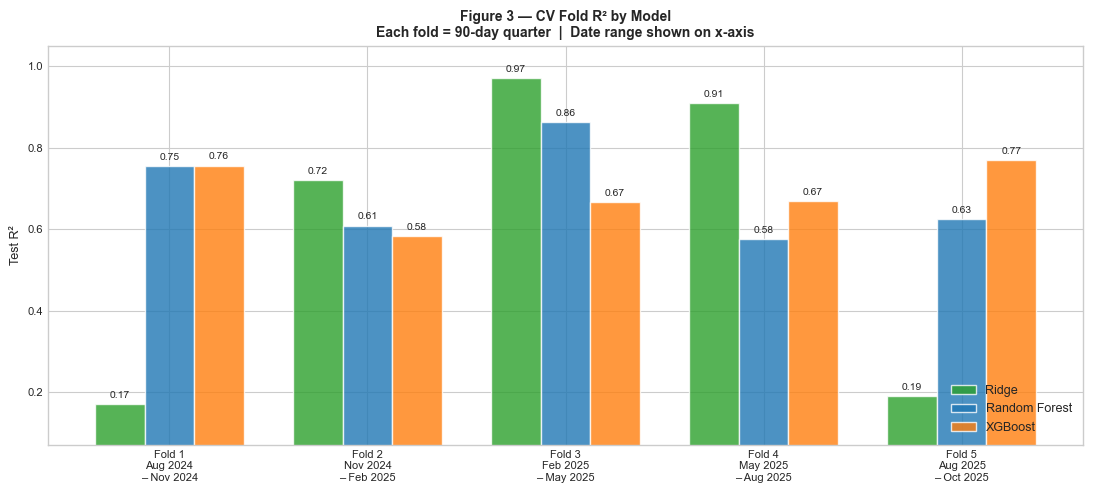

Saved: outputs/figures/model_03_cv_fold_r2.png


In [9]:
model_names = list(all_summ.keys())
n = len(model_names)
fold_labels = [f'Fold {i+1}' for i in range(N_SPLITS)]
x = np.arange(N_SPLITS)
width = 0.75 / n
colors_bar = ['#2ca02c', '#1f77b4', '#ff7f0e']

fig, ax = plt.subplots(figsize=(11, 5))

for i, (mname, color) in enumerate(zip(model_names, colors_bar)):
    r2_vals = all_summ[mname]['fold_r2']
    offset  = (i - (n - 1) / 2) * width
    bars    = ax.bar(x + offset, r2_vals, width, label=mname,
                     color=color, alpha=0.80, edgecolor='white')
    for bar, val in zip(bars, r2_vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                max(val + 0.01, 0.02),
                f'{val:.2f}', ha='center', va='bottom', fontsize=7.5)

# Use the same tscv object for consistent fold date labels
fold_dates = []
for _, test_idx in tscv.split(X_tree):
    start = pd.Timestamp(dates[test_idx[0]]).strftime('%b %Y')
    end   = pd.Timestamp(dates[test_idx[-1]]).strftime('%b %Y')
    fold_dates.append(f'{start}\n– {end}')

ax.set_xticks(x)
ax.set_xticklabels([f'{fl}\n{fd}' for fl, fd in zip(fold_labels, fold_dates)],
                   fontsize=8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Test R²', fontsize=9)
ax.set_ylim(min(min(s['fold_r2']) for s in all_summ.values()) - 0.1, 1.05)
ax.tick_params(axis='y', labelsize=8)
ax.legend(fontsize=9, loc='lower right')
ax.set_title(
    'Figure 3 — CV Fold R² by Model\n'
    'Each fold = 90-day quarter  |  Date range shown on x-axis',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig('outputs/figures/model_03_cv_fold_r2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/model_03_cv_fold_r2.png')
